In [71]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import re
from datetime import datetime
import openpyxl as op
from pathlib import Path
import seaborn as sns

In [72]:
# folder containing your *_bottom.csv files
folder = Path('Math_232_Data/jump_data_clean')

# collect all DataFrames here
dfs_bottom = []

for fp in folder.glob('*_bottom.csv'):
    # extract label = first part of filename before the first underscore
    label = fp.name.split('_', 1)[0]
    
    # read in the CSV
    df = pd.read_csv(fp)
    
    # add the label column
    df['label'] = label
    
    # store
    dfs_bottom.append(df)

# concatenate into one DataFrame
combined_df_bottom = pd.concat(dfs_bottom, ignore_index=True)

# now combined_df has all rows, with a 'label' column
print(combined_df_bottom.shape)

(206, 173)


In [73]:
# collect all DataFrames here
dfs_top = []

for fp in folder.glob('*_top.csv'):
    # extract label = first part of filename before the first underscore
    label = fp.name.split('_', 1)[0]
    
    # read in the CSV
    df = pd.read_csv(fp)
    
    # add the label column
    df['label'] = label
    
    # store
    dfs_top.append(df)

# concatenate into one DataFrame
combined_df_top = pd.concat(dfs_top, ignore_index=True)

# now combined_df has all rows, with a 'label' column
print(combined_df_top.shape)

(206, 173)


In [74]:
combined_df_bottom.head()

,Jump_Number,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,...,time_step_163,time_step_164,time_step_165,time_step_166,time_step_167,time_step_168,time_step_169,time_step_170,time_step_171,label
0,1,1080.88,1104.32,1127.52,1148.08,1165.04,1175.52,1183.92,1187.32,1189.48,...,597.76,648.68,711.96,779.96,851.44,917.80,953.92,973.44,979.64,Chu
1,2,514.60,528.04,542.04,566.08,597.76,648.68,711.96,779.96,851.44,...,947.48,875.40,761.08,651.60,545.04,447.24,394.92,416.64,465.16,Chu
2,3,790.36,836.56,896.40,938.00,970.04,986.04,988.40,981.72,980.00,...,1080.92,1104.04,1126.08,1139.56,1141.92,1138.16,1109.48,1066.20,1011.16,Chu
3,4,982.44,1010.76,1025.32,1025.56,1008.12,977.16,945.44,915.88,889.32,...,988.84,991.52,989.04,991.40,992.16,993.12,995.24,1025.04,1050.72,Chu
4,5,1064.44,1053.80,1039.56,1024.32,1011.84,999.08,991.52,988.84,991.52,...,1081.12,1077.20,1066.88,1056.32,1046.00,1032.32,1018.28,1009.80,999.16,Chu


In [75]:
combined_df_bottom_ti = combined_df_bottom.iloc[:, :-1]

In [76]:
combined_df_bottom_ti.head()

,Jump_Number,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,...,time_step_162,time_step_163,time_step_164,time_step_165,time_step_166,time_step_167,time_step_168,time_step_169,time_step_170,time_step_171
0,1,1080.88,1104.32,1127.52,1148.08,1165.04,1175.52,1183.92,1187.32,1189.48,...,566.08,597.76,648.68,711.96,779.96,851.44,917.80,953.92,973.44,979.64
1,2,514.60,528.04,542.04,566.08,597.76,648.68,711.96,779.96,851.44,...,1001.44,947.48,875.40,761.08,651.60,545.04,447.24,394.92,416.64,465.16
2,3,790.36,836.56,896.40,938.00,970.04,986.04,988.40,981.72,980.00,...,1054.56,1080.92,1104.04,1126.08,1139.56,1141.92,1138.16,1109.48,1066.20,1011.16
3,4,982.44,1010.76,1025.32,1025.56,1008.12,977.16,945.44,915.88,889.32,...,991.52,988.84,991.52,989.04,991.40,992.16,993.12,995.24,1025.04,1050.72
4,5,1064.44,1053.80,1039.56,1024.32,1011.84,999.08,991.52,988.84,991.52,...,1081.16,1081.12,1077.20,1066.88,1056.32,1046.00,1032.32,1018.28,1009.80,999.16


In [77]:
combined_df_top.head()

,Jump_Number,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,...,time_step_163,time_step_164,time_step_165,time_step_166,time_step_167,time_step_168,time_step_169,time_step_170,time_step_171,label
0,1,87.08,87.84,88.52,88.84,88.96,89.40,90.28,91.24,92.32,...,97.44,97.04,96.80,96.80,97.40,98.04,98.32,98.52,98.48,NoahJung
1,2,97.24,96.96,96.80,96.40,96.20,95.56,94.84,94.24,93.96,...,10.84,11.24,11.92,12.76,14.00,16.24,19.20,22.24,25.32,NoahJung
2,3,49.56,54.32,59.48,65.20,71.16,75.68,79.24,82.68,85.56,...,9.52,9.48,9.52,9.52,9.64,9.68,9.80,9.96,10.40,NoahJung
3,4,85.60,84.44,83.92,84.48,85.92,87.68,89.88,92.56,94.44,...,115.24,116.20,117.00,117.48,117.92,118.36,118.56,119.08,120.00,NoahJung
4,5,124.68,124.80,125.00,125.24,125.48,125.84,126.12,126.52,127.28,...,81.60,81.80,82.00,82.24,82.56,82.92,83.64,84.52,85.36,NoahJung


In [78]:
combined_df_top_ti = combined_df_top.iloc[:, 1:]

In [79]:
combined_df_top_ti.head()

,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,time_step_10,...,time_step_163,time_step_164,time_step_165,time_step_166,time_step_167,time_step_168,time_step_169,time_step_170,time_step_171,label
0,87.08,87.84,88.52,88.84,88.96,89.40,90.28,91.24,92.32,93.08,...,97.44,97.04,96.80,96.80,97.40,98.04,98.32,98.52,98.48,NoahJung
1,97.24,96.96,96.80,96.40,96.20,95.56,94.84,94.24,93.96,93.48,...,10.84,11.24,11.92,12.76,14.00,16.24,19.20,22.24,25.32,NoahJung
2,49.56,54.32,59.48,65.20,71.16,75.68,79.24,82.68,85.56,87.20,...,9.52,9.48,9.52,9.52,9.64,9.68,9.80,9.96,10.40,NoahJung
3,85.60,84.44,83.92,84.48,85.92,87.68,89.88,92.56,94.44,95.64,...,115.24,116.20,117.00,117.48,117.92,118.36,118.56,119.08,120.00,NoahJung
4,124.68,124.80,125.00,125.24,125.48,125.84,126.12,126.52,127.28,128.12,...,81.60,81.80,82.00,82.24,82.56,82.92,83.64,84.52,85.36,NoahJung


# Concatenate by columns

In [80]:
all_df = pd.concat([combined_df_bottom_ti, combined_df_top_ti], axis = 1, ignore_index=True)

In [81]:
all_df.head()

,0,1,2,3,4,5,6,7,8,9,...,334,335,336,337,338,339,340,341,342,343
0,1,1080.88,1104.32,1127.52,1148.08,1165.04,1175.52,1183.92,1187.32,1189.48,...,97.44,97.04,96.80,96.80,97.40,98.04,98.32,98.52,98.48,NoahJung
1,2,514.60,528.04,542.04,566.08,597.76,648.68,711.96,779.96,851.44,...,10.84,11.24,11.92,12.76,14.00,16.24,19.20,22.24,25.32,NoahJung
2,3,790.36,836.56,896.40,938.00,970.04,986.04,988.40,981.72,980.00,...,9.52,9.48,9.52,9.52,9.64,9.68,9.80,9.96,10.40,NoahJung
3,4,982.44,1010.76,1025.32,1025.56,1008.12,977.16,945.44,915.88,889.32,...,115.24,116.20,117.00,117.48,117.92,118.36,118.56,119.08,120.00,NoahJung
4,5,1064.44,1053.80,1039.56,1024.32,1011.84,999.08,991.52,988.84,991.52,...,81.60,81.80,82.00,82.24,82.56,82.92,83.64,84.52,85.36,NoahJung


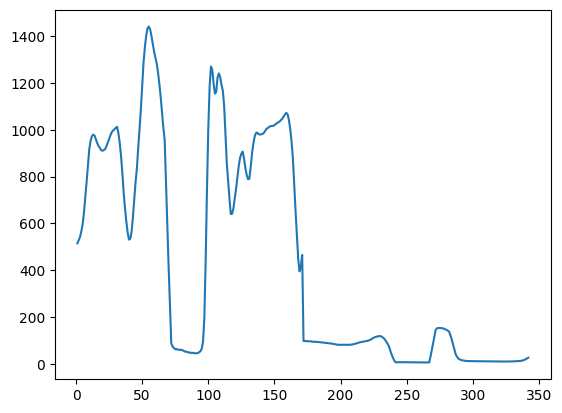

In [90]:
plt.plot(all_df.iloc[1, 1:343])

The first 171 are bottom, second 171 are top

In [82]:
# PCA
data = all_df.iloc[:, 1:343]

X = data.values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (206, 206)
s shape: (206,)
Vt shape: (206, 342)


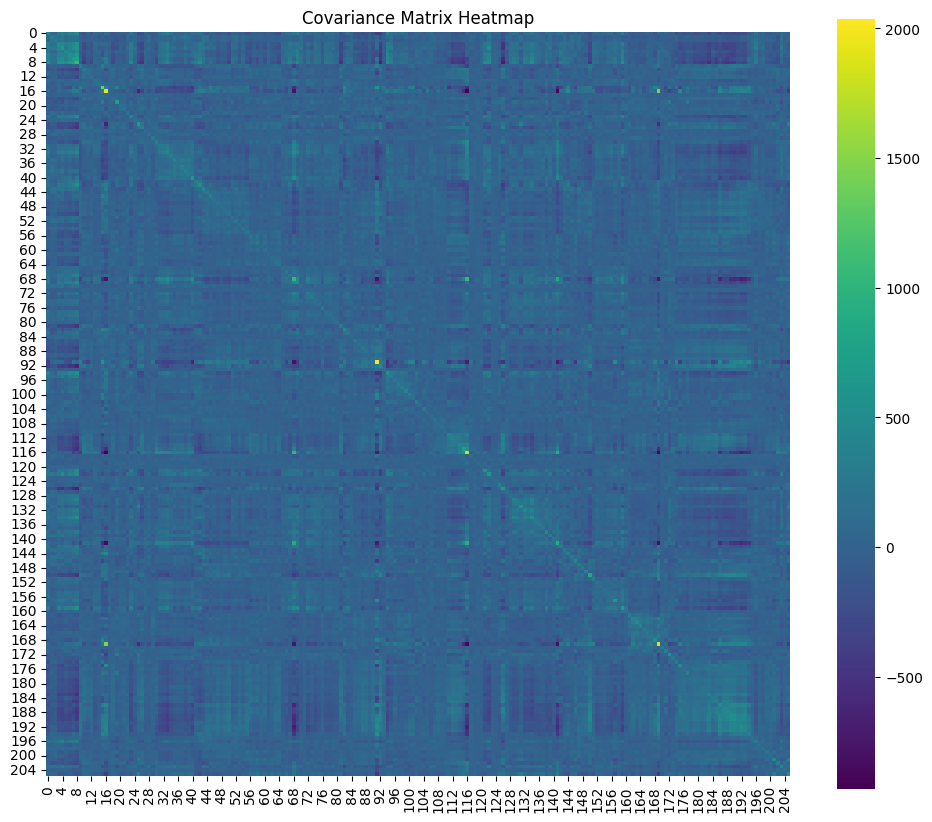

Shape of covariance matrix: (206, 206)

Maximum value: 2037.3840104248472
Minimum value: -931.7334207762292
Mean value: -1.3930897260637274e-16


In [83]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

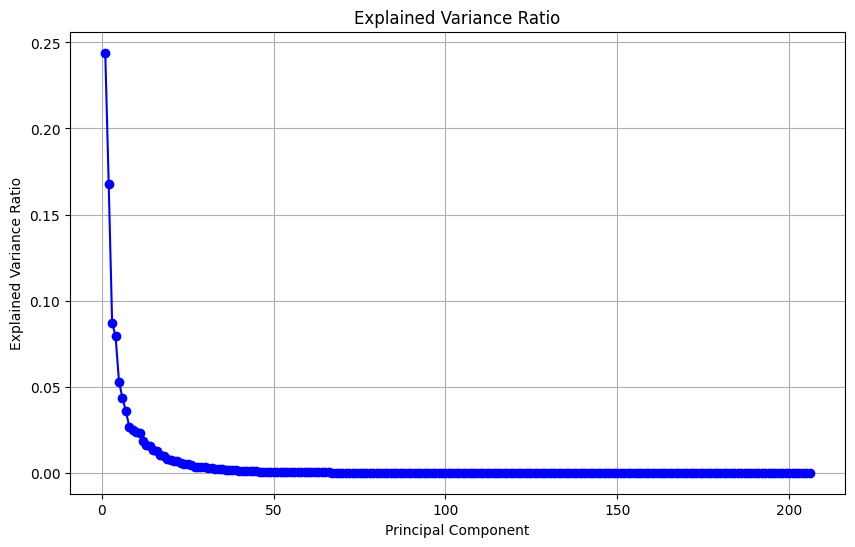

In [84]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [85]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.2440
PC2: 0.4119
PC3: 0.4991
PC4: 0.5785
PC5: 0.6313
PC6: 0.6748
PC7: 0.7106
PC8: 0.7373
PC9: 0.7623
PC10: 0.7862
PC11: 0.8090
PC12: 0.8271
PC13: 0.8432
PC14: 0.8587
PC15: 0.8716
PC16: 0.8840
PC17: 0.8945
PC18: 0.9041
PC19: 0.9123
PC20: 0.9196
PC21: 0.9266
PC22: 0.9332
PC23: 0.9391
PC24: 0.9444
PC25: 0.9493
PC26: 0.9537
PC27: 0.9572
PC28: 0.9606
PC29: 0.9638
PC30: 0.9669
PC31: 0.9697
PC32: 0.9722
PC33: 0.9745
PC34: 0.9767
PC35: 0.9786
PC36: 0.9803
PC37: 0.9818
PC38: 0.9832
PC39: 0.9846
PC40: 0.9858
PC41: 0.9869
PC42: 0.9880
PC43: 0.9890
PC44: 0.9899
PC45: 0.9907
PC46: 0.9914
PC47: 0.9921
PC48: 0.9928
PC49: 0.9933
PC50: 0.9939
PC51: 0.9944
PC52: 0.9948
PC53: 0.9952
PC54: 0.9956
PC55: 0.9959
PC56: 0.9963
PC57: 0.9965
PC58: 0.9968
PC59: 0.9970
PC60: 0.9972
PC61: 0.9975
PC62: 0.9976
PC63: 0.9978
PC64: 0.9980
PC65: 0.9981
PC66: 0.9983
PC67: 0.9984
PC68: 0.9985
PC69: 0.9986
PC70: 0.9987
PC71: 0.9988
PC72: 0.9989
PC73: 0.9989
PC74: 0.9990
PC75: 0.99

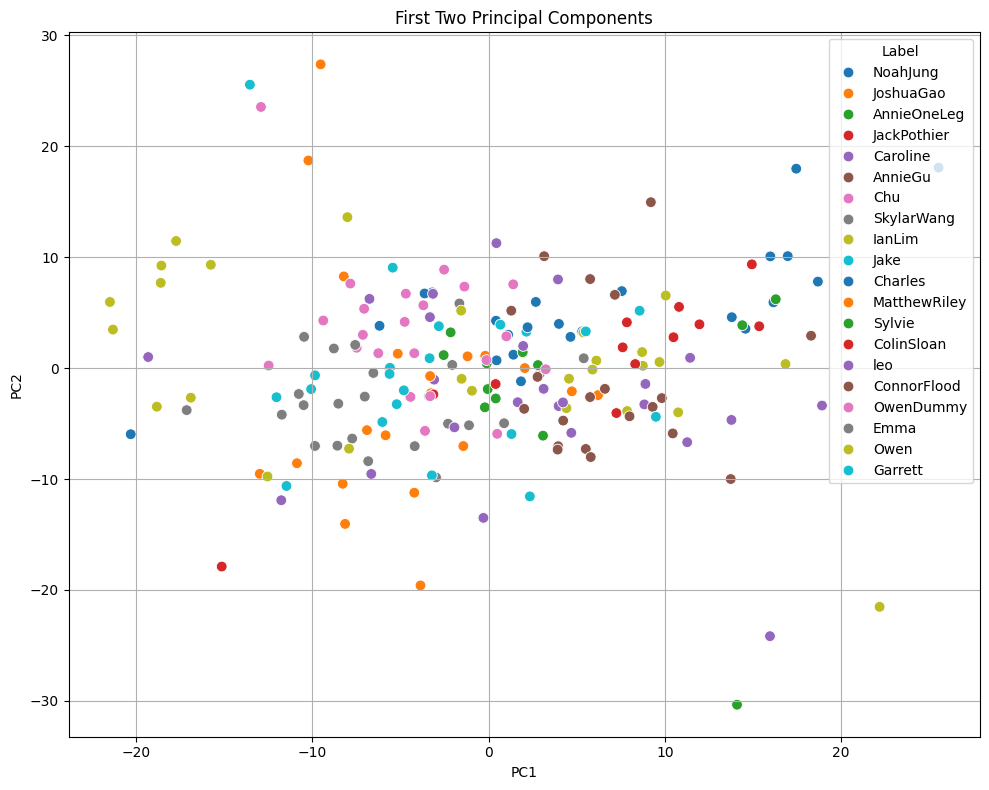

In [86]:
# Plot the first two principal components
labels = all_df.iloc[:, -1]
pca_df = pd.DataFrame({
    'PC1': scores[:, 0],
    'PC2': scores[:, 1],
    'Label': labels  # categorical labels, e.g., 'annie', 'bob'
})

# Plot with seaborn: hue assigns color by label
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Label', palette='tab10', s=60)

plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()